Крок 0: Підготовка даних (Це обов'язково запустити першим!)
Цей блок створює головну таблицю df, на яку будуть посилатися всі наступні графіки.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/Vadimkin/ukrainian-air-raid-sirens-dataset/main/datasets/official_data_uk.csv"
df = pd.read_csv(url)
df['started_at'] = pd.to_datetime(df['started_at']).dt.tz_convert('Europe/Kyiv')
df['finished_at'] = pd.to_datetime(df['finished_at']).dt.tz_convert('Europe/Kyiv')
df['duration_hours'] = (df['finished_at'] - df['started_at']).dt.total_seconds() / 3600
df['year_month'] = df['started_at'].dt.to_period('M').dt.to_timestamp()
print("Дані підготовлено успішно!")

Дані підготовлено успішно!


/tmp/ipykernel_1034/4036582625.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['year_month'] = df['started_at'].dt.to_period('M').dt.to_timestamp()


Графік 1: Кількість тривог по місяцях

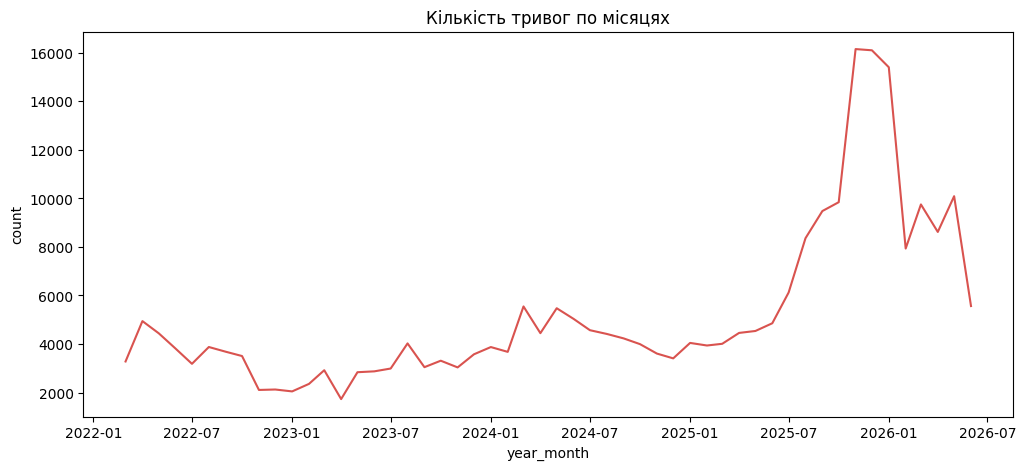

In [2]:
monthly = df.groupby('year_month').size().reset_index(name='count')
plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly, x='year_month', y='count', color='#d9534f')
plt.title('Кількість тривог по місяцях')
plt.show()

Графік 2: Сумарна тривалість (годин) по місяцях

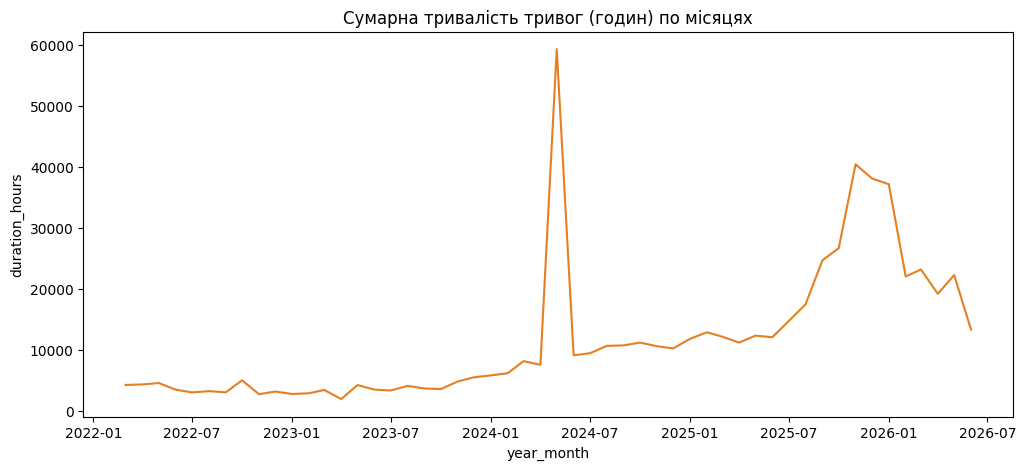

In [3]:
dur_monthly = df.groupby('year_month')['duration_hours'].sum().reset_index()
plt.figure(figsize=(12, 5))
sns.lineplot(data=dur_monthly, x='year_month', y='duration_hours', color='#e67e22')
plt.title('Сумарна тривалість тривог (годин) по місяцях')
plt.show()

Графік 3: Теплова карта (Вінницька область)
(Щоб змінити регіон, заміни 'Вінницька область' на потрібну назву)

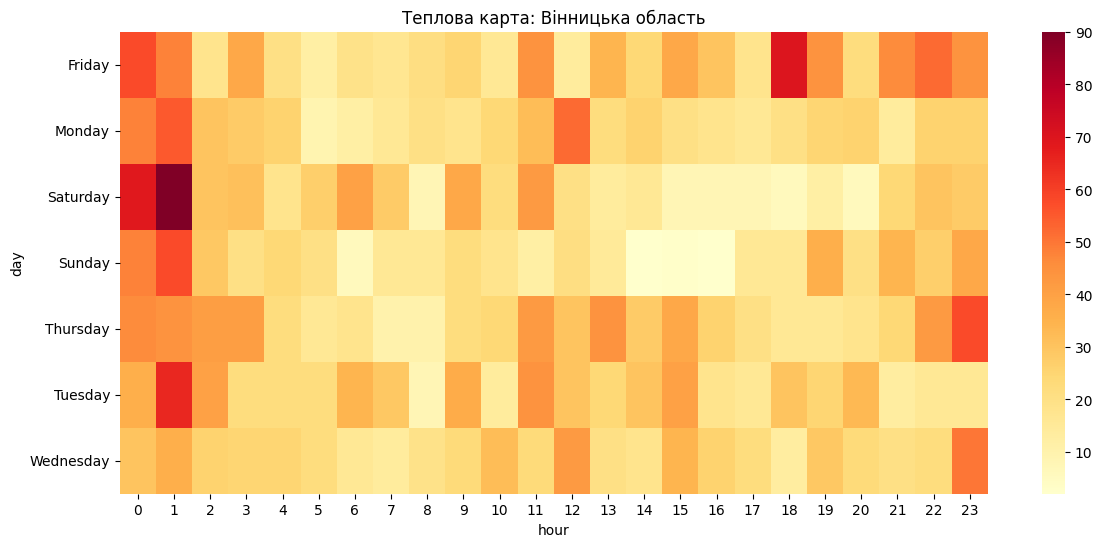

In [4]:
region = 'Вінницька область'
df_reg = df[df['oblast'] == region].copy()
df_reg['hour'] = df_reg['started_at'].dt.hour
df_reg['day'] = df_reg['started_at'].dt.day_name()
heatmap = df_reg.groupby(['day', 'hour']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 6))
sns.heatmap(heatmap, cmap='YlOrRd')
plt.title(f'Теплова карта: {region}')
plt.show()

Графік 4: 30-денне ковзне середнє (Вінницька область)
(Зміни регіон у змінній region аналогічно попередньому)

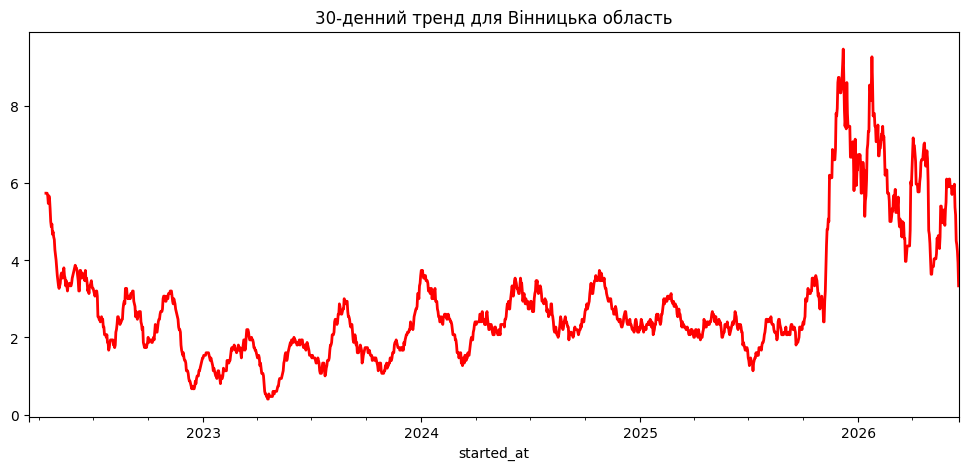

In [5]:
region = 'Вінницька область'
df_roll = df[df['oblast'] == region].set_index('started_at')
rolling = df_roll.resample('D').size().rolling(window=30).mean()

plt.figure(figsize=(12, 5))
rolling.plot(color='red', linewidth=2)
plt.title(f'30-денний тренд для {region}')
plt.show()

Графік 5: Кількість тривог за порами року

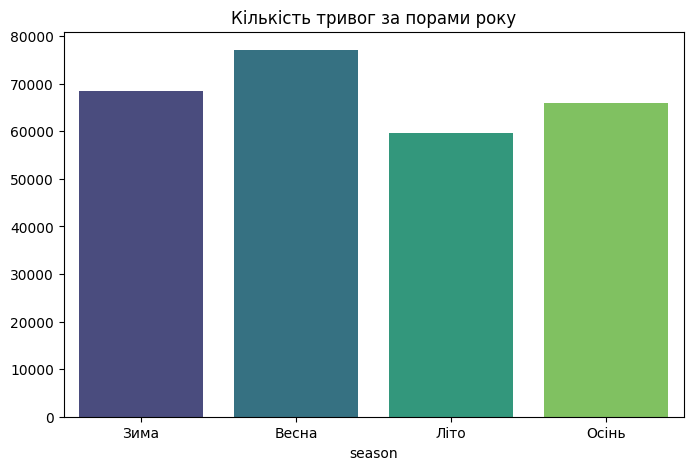

In [6]:
def get_season(m):
    return 'Зима' if m in [12,1,2] else 'Весна' if m in [3,4,5] else 'Літо' if m in [6,7,8] else 'Осінь'

df['season'] = df['started_at'].dt.month.apply(get_season)
season_data = df['season'].value_counts().reindex(['Зима', 'Весна', 'Літо', 'Осінь'])

plt.figure(figsize=(8, 5))
sns.barplot(x=season_data.index, y=season_data.values, hue=season_data.index, palette='viridis')
plt.title('Кількість тривог за порами року')
plt.show()

Графік 6: Кількість тривог у регіонах

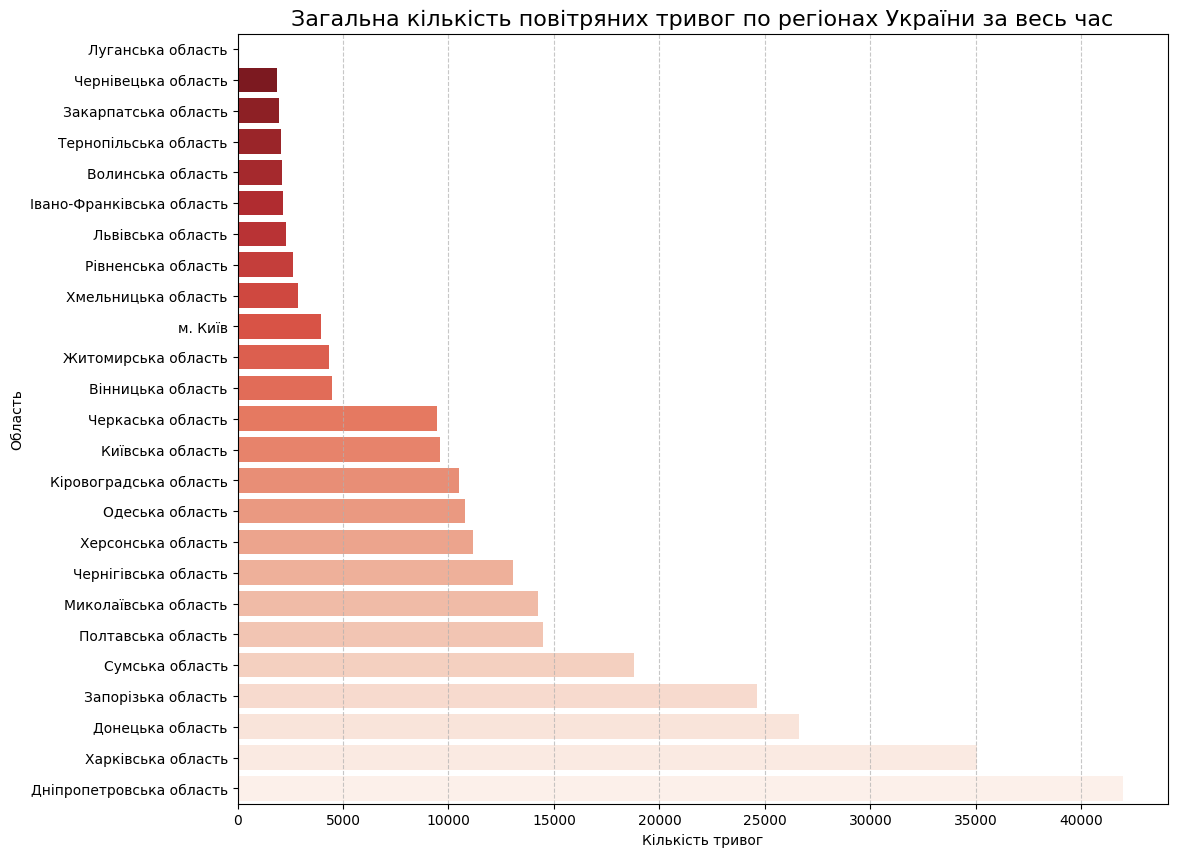

In [7]:
# 1. Рахуємо кількість тривог для кожного регіону (oblast)
region_counts = df.groupby('oblast').size().sort_values(ascending=True).reset_index(name='alert_count')

# 2. Побудова графіка
plt.figure(figsize=(12, 10))
sns.barplot(data=region_counts, x='alert_count', y='oblast', palette='Reds_r', hue='oblast', legend=False)

plt.title('Загальна кількість повітряних тривог по регіонах України за весь час', fontsize=16)
plt.xlabel('Кількість тривог')
plt.ylabel('Область')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()